## EJERCICIO EXTRA – Composición e inversa de poses

El objetivo de este ejercicio es **aplicar las operaciones de composición e inversa de poses** para describir el movimiento de un robot móvil en el plano.



In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:

def compose(p1, p2):
    """Devuelve p1 ⊕ p2"""
    x1, y1, th1 = p1
    dx, dy, dth = p2
    c, s = np.cos(th1), np.sin(th1)
    x = x1 + c * dx - s * dy
    y = y1 + s * dx + c * dy
    th = th1 + dth
    # normaliza ángulo a [-pi, pi]
    th = (th + np.pi) % (2*np.pi) - np.pi
    return np.array([x, y, th])


In [3]:

def inverse(p):
    """Devuelve ⊖p"""
    x, y, th = p
    c, s = np.cos(th), np.sin(th)
    x_inv = -c*x - s*y
    y_inv =  s*x - c*y
    th_inv = -th
    return np.array([x_inv, y_inv, th_inv])


Poses intermedias:
p0 = [0. 0. 0.]
p1 = [1.         0.         0.78539816]
p2 = [1.35355339 0.35355339 0.26179939]
p3 = [2.07453024 0.75379379 0.26179939]

Pose final p3 = [2.07453024 0.75379379 0.26179939]
Inversa ⊖p3 = [-2.19893853 -0.19118095 -0.26179939]
Comprobación (⊖p3 ⊕ p3) = [1.38777878e-16 0.00000000e+00 0.00000000e+00]


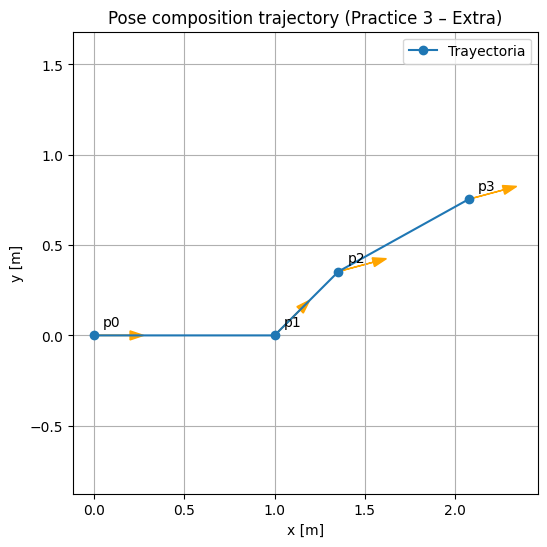

In [4]:

#  Datos 
p0 = np.array([0.0, 0.0, 0.0])
motions = [
    np.array([1.0, 0.0, np.pi/4]),
    np.array([0.5, 0.0, -np.pi/6]),
    np.array([0.8, 0.2, 0.0])
]

#  Propagación de las poses 
poses = [p0]
for dp in motions:
    new_pose = compose(poses[-1], dp)
    poses.append(new_pose)

poses = np.array(poses)

#  Resultados numéricos 
print("Poses intermedias:")
for i, p in enumerate(poses):
    print(f"p{i} = {p}")

#  Inversa de la pose final 
p_final = poses[-1]
inv_p = inverse(p_final)
check = compose(inv_p, p_final)

print("\nPose final p3 =", p_final)
print("Inversa ⊖p3 =", inv_p)
print("Comprobación (⊖p3 ⊕ p3) =", check)

#  Visualización 
plt.figure(figsize=(6,6))
plt.plot(poses[:,0], poses[:,1], 'o-', label="Trayectoria")
for i, p in enumerate(poses):
    plt.arrow(p[0], p[1], 0.2*np.cos(p[2]), 0.2*np.sin(p[2]),
              head_width=0.05, color='orange')
    plt.text(p[0]+0.05, p[1]+0.05, f"p{i}")
plt.grid(True)
plt.axis('equal')
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Pose composition trajectory (Practice 3 – Extra)")
plt.legend()
plt.show()
